In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

c:\Dexter\github\AsifAmir\LangGraph\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class StrikerState(TypedDict):

    goals: int
    shots: int
    shots_on_target: int
    matches: int
    assists: int

    shot_accuracy: float       # shots on target / shots * 100
    conversion_rate: float     # goals / shots * 100
    goals_per_match: float     # goals / matches
    goal_contribution: float   # (goals + assists) / matches
    summary: str

In [3]:
def calculate_shot_accuracy(state: StrikerState):

    shot_accuracy = (state['shots_on_target'] / state['shots']) * 100

    return {'shot_accuracy': shot_accuracy}

In [4]:
def calculate_conversion_rate(state: StrikerState):

    conversion_rate = (state['goals'] / state['shots']) * 100

    return {'conversion_rate': conversion_rate}

In [5]:
def calculate_goals_per_match(state: StrikerState):

    goals_per_match = state['goals'] / state['matches']

    return {'goals_per_match': goals_per_match}

In [6]:
def calculate_goal_contribution(state: StrikerState):

    goal_contribution = (state['goals'] + state['assists']) / state['matches']

    return {'goal_contribution': goal_contribution}

In [7]:
def summary(state: StrikerState):

    summary = f"""
Shot Accuracy       - {state['shot_accuracy']:.2f}% \n
Conversion Rate     - {state['conversion_rate']:.2f}% \n
Goals per Match     - {state['goals_per_match']:.2f} \n
Goal Contribution   - {state['goal_contribution']:.2f} per match
"""

    return {'summary': summary}

In [8]:
graph = StateGraph(StrikerState)

graph.add_node('calculate_shot_accuracy', calculate_shot_accuracy)
graph.add_node('calculate_conversion_rate', calculate_conversion_rate)
graph.add_node('calculate_goals_per_match', calculate_goals_per_match)
graph.add_node('calculate_goal_contribution', calculate_goal_contribution)
graph.add_node('summary', summary)

# edges - all calculations run in parallel from START
graph.add_edge(START, 'calculate_shot_accuracy')
graph.add_edge(START, 'calculate_conversion_rate')
graph.add_edge(START, 'calculate_goals_per_match')
graph.add_edge(START, 'calculate_goal_contribution')

# all calculations feed into summary
graph.add_edge('calculate_shot_accuracy', 'summary')
graph.add_edge('calculate_conversion_rate', 'summary')
graph.add_edge('calculate_goals_per_match', 'summary')
graph.add_edge('calculate_goal_contribution', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

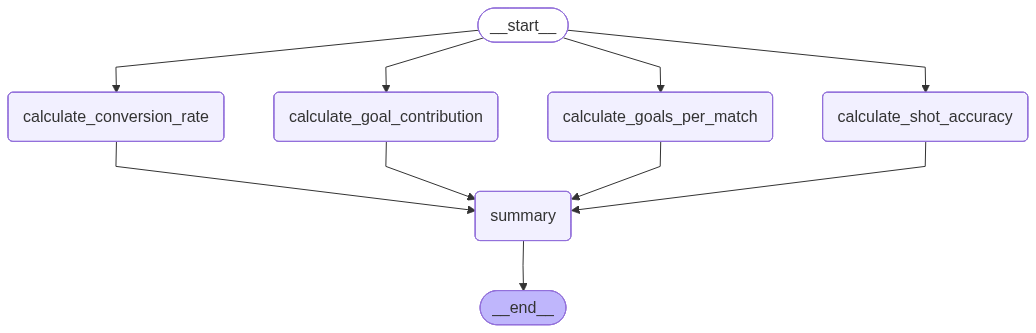

In [9]:
workflow

In [10]:
# Example: Erling Haaland-like stats for a season
initial_state = {
    'goals': 36,
    'shots': 113,
    'shots_on_target': 67,
    'matches': 35,
    'assists': 8
}

result = workflow.invoke(initial_state)
print(result['summary'])


Shot Accuracy       - 59.29% 

Conversion Rate     - 31.86% 

Goals per Match     - 1.03 

Goal Contribution   - 1.26 per match

